# Análisis de Estudiantes - Violencia Digital
Este notebook procesa exclusivamente los datos de estudiantes, integrando la limpieza de dimensiones demográficas y geográficas, y exporta la capa final para Power BI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
sns.set_theme(style="whitegrid")

# Crear carpeta output si no existe
os.makedirs('../output', exist_ok=True)

# Cargar datos crudos
df_estudiantes = pd.read_excel('../raw_data/BBDD_Estudiantes_dash.xlsx')

## 1. Cálculo de Índices (Conocimiento y Prevención)

In [2]:
def evaluar_conocimiento(df):
    col_q22 = '22. ¿Qué es el Grooming?'
    col_q23 = '23. ¿Qué es la Sextorsión?'
    col_q24 = '24. ¿Cuál de estos comportamientos consideras que es violencia sexual en línea?'
    col_q25 = '25. Cuál de estas acciones es considerada ciberacoso o "cyberbullying"?'
    col_q26 = '26. ¿Cuál de estas situaciones consideras una forma de violencia digital, aunque no sea de tipo sexual?\n(Puede marcar más de una opción)'
    
    df['Puntaje_Q22'] = df[col_q22].apply(lambda x: 1 if 'adulto contacta' in str(x).lower() else 0)
    df['Puntaje_Q23'] = df[col_q23].apply(lambda x: 1 if 'amenaza' in str(x).lower() or 'íntimas' in str(x).lower() else 0)
    df['Puntaje_Q24'] = df[col_q24].apply(lambda x: 1 if 'sin consentimiento' in str(x).lower() else 0)
    df['Puntaje_Q25'] = df[col_q25].apply(lambda x: 1 if 'ofensivos' in str(x).lower() or 'burlas' in str(x).lower() else 0)
    
    def puntaje_q26(texto):
        t = str(texto).lower()
        if 'todas las anteriores' in t: return 1
        if 'suplantación' in t or 'excluir' in t or 'falsa' in t: return 1
        return 0
        
    df['Puntaje_Q26'] = df[col_q26].apply(puntaje_q26)
    df['Indice_Conocimiento'] = df[['Puntaje_Q22', 'Puntaje_Q23', 'Puntaje_Q24', 'Puntaje_Q25', 'Puntaje_Q26']].sum(axis=1)
    return df

def calcular_indice_prevencion_final(df):
    col_q14 = '14. Cuando juegas en línea, ¿con quién juegas habitualmente?' 
    col_q15 = '15. Cuando juegas con personas desconocidas en línea, ¿qué tipo de información has compartido con ellas?\n(Puede marcar más de una opción)'
    col_q20 = '20. ¿Alguna vez sentiste presión para enviar fotos personales o íntimas a alguien por internet?'
    col_q28 = '28. Si alguien que no conoces te pide fotos personales por internet, ¿qué harías?'
    col_q29 = '29. ¿Qué haces normalmente con tu contraseña de redes sociales o correo electrónico?'
    col_q30 = '30. ¿Con qué frecuencia ajustas la configuración de privacidad de tus redes sociales?'
    col_q31 = '31. Antes de publicar una foto o video en redes sociales, ¿qué haces habitualmente?'
    
    df['Prev_Q14'] = df[col_q14].apply(lambda x: 1 if 'solo' in str(x).lower() or 'conozco en persona' in str(x).lower() else 0)
    df['Prev_Q15'] = df[col_q15].apply(lambda x: 1 if 'nunca comparto' in str(x).lower() else 0)
    df['Prev_Q20'] = df[col_q20].apply(lambda x: 1 if 'nunca' in str(x).lower() or 'me negué' in str(x).lower() else 0)
    df['Prev_Q28'] = df[col_q28].apply(lambda x: 1 if 'negarme' in str(x).lower() or 'bloquear' in str(x).lower() else 0)
    df['Prev_Q29'] = df[col_q29].apply(lambda x: 1 if 'nadie' in str(x).lower() or 'padres' in str(x).lower() else 0)
    df['Prev_Q30'] = df[col_q30].apply(lambda x: 1 if 'privado' in str(x).lower() or 'a veces' in str(x).lower() else 0)
    df['Prev_Q31'] = df[col_q31].apply(lambda x: 1 if 'aseguro' in str(x).lower() or 'nunca publico' in str(x).lower() else 0)
    df['Puntaje_Comportamiento'] = df[['Prev_Q14', 'Prev_Q15', 'Prev_Q20', 'Prev_Q28', 'Prev_Q29', 'Prev_Q30', 'Prev_Q31']].sum(axis=1)

    cols_q19 = [
        '19. ¿Qué tanto conoces sobre los siguientes temas para protegerte en internet? \nMarca tu nivel de conocimiento: [PRIVACIDAD DIGITAL (proteger tus datos y fotos personales)]',
        '19. ¿Qué tanto conoces sobre los siguientes temas para protegerte en internet? \nMarca tu nivel de conocimiento: [CIBERACOSO (acoso o burlas repetidas por internet)]',
        '19. ¿Qué tanto conoces sobre los siguientes temas para protegerte en internet? \nMarca tu nivel de conocimiento: [SEGURIDAD DIGITAL (contraseñas, configuración de privacidad)]',
        '19. ¿Qué tanto conoces sobre los siguientes temas para protegerte en internet? \nMarca tu nivel de conocimiento: [DERECHOS DIGITALES (tus derechos como usuario/a en internet)]',
        '19. ¿Qué tanto conoces sobre los siguientes temas para protegerte en internet? \nMarca tu nivel de conocimiento: [USO RESPONSABLE DE INTERNET Y REDES SOCIALES]'
    ]
    for col in cols_q19:
        df[col + '_num'] = df[col].astype(str).str.extract(r'(\d+)')[0].astype(float).fillna(0)
    df['Puntaje_Q19'] = df[[col + '_num' for col in cols_q19]].sum(axis=1)

    cols_q27 = [
        '27. ¿Qué tanto conoces sobre los siguientes riesgos del uso de la Inteligencia Artificial (IA) en internet?\nMarca tu nivel de conocimiento: [DEEPFAKES (videos o fotos falsas creadas con IA para hacerse pasar por alguien)]',
        '27. ¿Qué tanto conoces sobre los siguientes riesgos del uso de la Inteligencia Artificial (IA) en internet?\nMarca tu nivel de conocimiento: [VOZ ARTIFICIAL (audios falsos generados con IA imitando la voz de una persona)]',
        '27. ¿Qué tanto conoces sobre los siguientes riesgos del uso de la Inteligencia Artificial (IA) en internet?\nMarca tu nivel de conocimiento: [IMÁGENES ÍNTIMAS FALSAS GENERADAS CON IA SIN CONSENTIMIENTO DE LA PERSONA]',
        '27. ¿Qué tanto conoces sobre los siguientes riesgos del uso de la Inteligencia Artificial (IA) en internet?\nMarca tu nivel de conocimiento: [CHATBOTS QUE SE HACEN PASAR POR PERSONAS REALES PARA ENGAÑAR O MANIPULAR]',
        '27. ¿Qué tanto conoces sobre los siguientes riesgos del uso de la Inteligencia Artificial (IA) en internet?\nMarca tu nivel de conocimiento: [USO DE LA IA PARA ROBAR O SUPLANTAR IDENTIDADES DIGITAL]'
    ]
    def convertir_escala_conocimiento(texto):
        t = str(texto).lower()
        if 'nada' in t: return 1
        if 'poco' in t: return 2
        if 'bastante' in t: return 3
        if 'bien' in t: return 4
        return 0
    for col in cols_q27:
        df[col + '_num'] = df[col].apply(convertir_escala_conocimiento)
    df['Puntaje_Q27'] = df[[col + '_num' for col in cols_q27]].sum(axis=1)

    df['Indice_Prevencion'] = df['Puntaje_Comportamiento'] + df['Puntaje_Q19'] + df['Puntaje_Q27']
    return df

df_estudiantes = evaluar_conocimiento(df_estudiantes)
df_estudiantes = calcular_indice_prevencion_final(df_estudiantes)

# Normalización a escala 0-100 para facilitar visualización en Power BI
df_estudiantes['Indice_Conocimiento_Norm'] = (df_estudiantes['Indice_Conocimiento'] / df_estudiantes['Indice_Conocimiento'].max()) * 100
df_estudiantes['Indice_Prevencion_Norm'] = (df_estudiantes['Indice_Prevencion'] / df_estudiantes['Indice_Prevencion'].max()) * 100

print("Índices calculados y normalizados a 100 correctamente.")

Índices calculados y normalizados a 100 correctamente.


## 2. Limpieza de Dimensiones Geográficas y Demográficas

In [3]:
# 1. Municipio
df_estudiantes['Dim_Municipio'] = df_estudiantes['Municipio'].astype(str).str.strip().str.title()
df_estudiantes['Dim_Municipio'] = df_estudiantes['Dim_Municipio'].replace('Nan', 'No Reportado')

# 2. Edad y Rango de Edad (manteniendo la columna original 'D1. ¿Cuantos años tienes?')
import re
def categorizar_edad(edad):
    numeros = re.findall(r'\d+', str(edad))
    if not numeros:
        return 'No Reportado'
    try:
        e = int(numeros[0])
        if e <= 12: return '12 o menos'
        elif e <= 15: return '13 a 15 años'
        elif e <= 18: return '16 a 18 años'
        else: return 'Mayor de 18'
    except:
        return 'No Reportado'

df_estudiantes['Dim_Rango_Edad'] = df_estudiantes['D1. ¿Cuantos años tienes?'].apply(categorizar_edad)

# 3. Grado/Curso
col_grado = 'D3. ¿En que grado o curso estás actualmente?'
df_estudiantes['Dim_Grado'] = df_estudiantes[col_grado].astype(str).str.strip().str.title()
df_estudiantes['Dim_Grado'] = df_estudiantes['Dim_Grado'].replace('Nan', 'No Reportado')

# 4. Entorno (Urbano/Rural)
col_entorno = 'D4. ¿Cómo describirías el lugar donde vives?'
df_estudiantes['Dim_Entorno'] = df_estudiantes[col_entorno].astype(str).str.strip().str.title()
df_estudiantes['Dim_Entorno'] = df_estudiantes['Dim_Entorno'].replace('Nan', 'No Reportado')

# 5. Unidad Educativa
col_ue = 'Unidad Educativa'
df_estudiantes['Dim_Unidad_Educativa'] = df_estudiantes[col_ue].astype(str).str.strip().str.title()
df_estudiantes['Dim_Unidad_Educativa'] = df_estudiantes['Dim_Unidad_Educativa'].replace('Nan', 'No Reportado')

# 6. Idioma Materno
col_idioma = '¿Cual es tu idioma materno?'
df_estudiantes['Dim_Idioma'] = df_estudiantes[col_idioma].astype(str).str.strip().str.title()
df_estudiantes['Dim_Idioma'] = df_estudiantes['Dim_Idioma'].replace('Nan', 'No Reportado')

print("Dimensiones limpiadas y creadas.")

Dimensiones limpiadas y creadas.


## 3. Visualizaciones Intermedias (Pruebas)

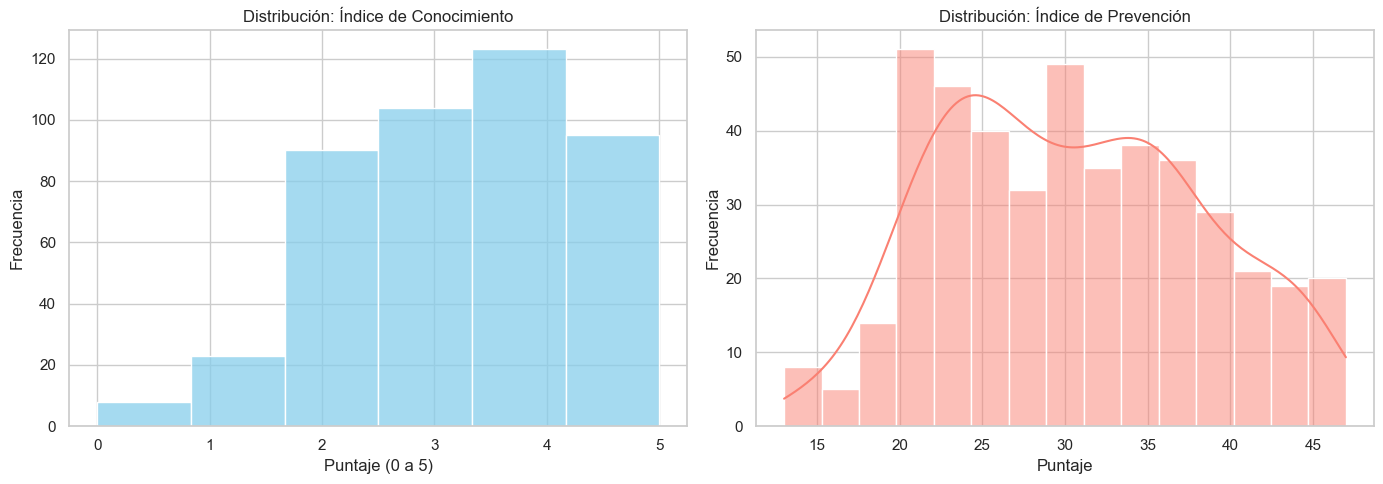

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma: Indice de Conocimiento
sns.histplot(df_estudiantes['Indice_Conocimiento'], bins=6, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución: Índice de Conocimiento')
axes[0].set_xlabel('Puntaje (0 a 5)')
axes[0].set_ylabel('Frecuencia')

# Histograma: Indice de Prevencion
sns.histplot(df_estudiantes['Indice_Prevencion'], bins=15, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución: Índice de Prevención')
axes[1].set_xlabel('Puntaje')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

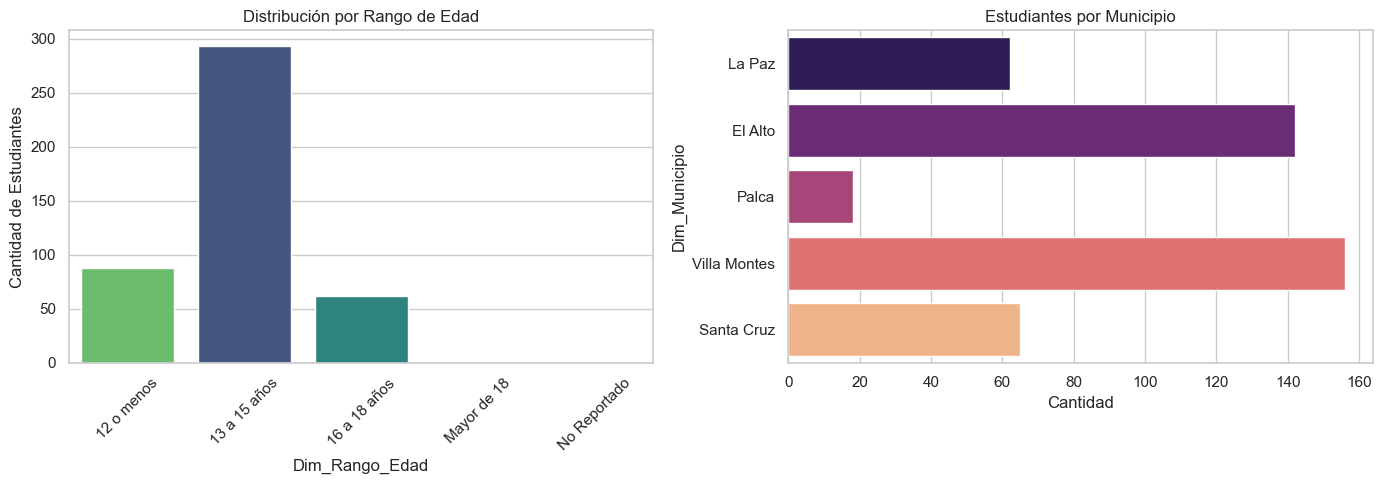

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras: Rango de Edades
sns.countplot(data=df_estudiantes, x='Dim_Rango_Edad', order=['12 o menos', '13 a 15 años', '16 a 18 años', 'Mayor de 18', 'No Reportado'], ax=axes[0], hue='Dim_Rango_Edad', legend=False, palette='viridis')
axes[0].set_title('Distribución por Rango de Edad')
axes[0].set_ylabel('Cantidad de Estudiantes')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de barras: Municipio
sns.countplot(data=df_estudiantes, y='Dim_Municipio', ax=axes[1], hue='Dim_Municipio', legend=False, palette='magma')
axes[1].set_title('Estudiantes por Municipio')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

## 4. Exportación de Resultados
Guardamos las columnas relevantes para Power BI, incluyendo todas las dimensiones generadas, la edad original y el género intacto.

In [6]:
# Seleccionamos las columnas clave para el Dashboard
columnas_finales = [
    'ID_Control', # Asumiendo que existe una llave primaria
    'Dim_Municipio',
    'D2. ¿Género?', # El género se mantiene original
    'D1. ¿Cuantos años tienes?', # Edad original
    'Dim_Rango_Edad',
    'Dim_Grado',
    'Dim_Entorno',
    'Dim_Unidad_Educativa',
    'Dim_Idioma',
    'Indice_Conocimiento_Norm',
    'Indice_Prevencion_Norm'
]

# Validamos que las columnas existan en el df original antes de exportar
cols_export = [c for c in columnas_finales if c in df_estudiantes.columns]

df_final = df_estudiantes[cols_export].copy()

output_path = '../output/df_estudiantes_final.xlsx'
df_final.to_excel(output_path, index=False)
print(f"Archivo final exportado exitosamente a: {output_path}")

Archivo final exportado exitosamente a: ../output/df_estudiantes_final.xlsx
